# Этап 2.


- сравнить графики сходимости со стадией 1;
- реализовать подстановку в исходной системе;
- учесть, что после подстановки максимальный порядок производной равен 2;
- добавить граничные условия для `v`;
- сравнить 3 варианта архитектуры:
  1. одна сеть с двумя выходами `[u, v]`;
  2. две отдельные сети;
  3. общие слои + раздельные головы.

Идея шаблона: вы сами дописываете формулы, а все основные блоки уже разложены по местам.

In [18]:
import platform
print(platform.processor())

Intel64 Family 6 Model 140 Stepping 1, GenuineIntel


In [19]:
import json
import math
import re
from pathlib import Path
from time import time

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True


## 1. Общие настройки

In [20]:
PREFER_ACCELERATOR = True
CPU_DTYPE = 'float64'
ACCELERATOR_DTYPE = 'float32'

def detect_training_device():
    for device_type, device_name in (('GPU', '/GPU:0'), ('XPU', '/XPU:0')):
        try:
            devices = tf.config.list_physical_devices(device_type)
        except Exception:
            devices = []

        if devices:
            if device_type == 'GPU':
                for device in devices:
                    try:
                        tf.config.experimental.set_memory_growth(device, True)
                    except Exception:
                        pass
            return device_name, device_type, devices

    return '/CPU:0', 'CPU', tf.config.list_physical_devices('CPU')

TRAINING_DEVICE, DEVICE_KIND, AVAILABLE_DEVICES = detect_training_device()
DTYPE = ACCELERATOR_DTYPE if (PREFER_ACCELERATOR and DEVICE_KIND != 'CPU') else CPU_DTYPE
tf.keras.backend.set_floatx(DTYPE)

SEED = 1234
tf.random.set_seed(SEED)
np.random.seed(SEED)

device_names = [device.name for device in AVAILABLE_DEVICES]
print('training device:', TRAINING_DEVICE)
print('device kind:', DEVICE_KIND)
print('visible devices:', device_names)
print('float type:', tf.keras.backend.floatx())
print('seed:', SEED)
if DEVICE_KIND == 'CPU':
    print('note: current TensorFlow runtime did not detect a GPU/XPU; Intel Iris Xe will be used only if the notebook kernel has a compatible GPU backend.')


training device: /CPU:0
device kind: CPU
visible devices: ['/physical_device:CPU:0']
float type: float64
seed: 1234
note: current TensorFlow runtime did not detect a GPU/XPU; Intel Iris Xe will be used only if the notebook kernel has a compatible GPU backend.


## 2. Параметры задачи

Здесь оставьте ваши реальные значения области, размеров выборок, коэффициентов уравнения и весов лосса.

In [21]:
# Область и размеры выборок берем по мотивам лабы 1
tmin, tmax = 0.0, 4.0
xmin, xmax = -30.0, 30.0

# Размеры выборок
N_0 = 300
N_r = 20000
N_b = 2000

# Коэффициенты и точное решение из лабы 1
b = tf.constant(5.0, dtype=DTYPE)
k = tf.constant(0.5 * np.sqrt(11.0 / 19.0), dtype=DTYPE)
c = tf.constant((15.0 / 19.0) * np.sqrt(11.0 / 19.0), dtype=DTYPE)
x0 = tf.constant(-12.0, dtype=DTYPE)
us = tf.constant(10.0, dtype=DTYPE)

# Гиперпараметры для этапа 2
# Архитектуры оставлены максимально близкими к лабе 1,
# а число шагов снижено до разумного для запуска на ноутбуке.
NUM_HIDDEN_LAYERS = 4
NUM_SHARED_LAYERS = 4
HIDDEN_DIM = 64
NUM_FOURIER = 16
ACTIVATION = 'tanh'
LEARNING_RATE = 2e-4
NUM_STEPS = 3000
PRINT_EVERY = 100
PLOT_EVERY = 2000
PLOT_NUM_X = 256


lambda_r = tf.constant(1.0, dtype=DTYPE)
lambda_b = tf.constant(1.0, dtype=DTYPE)
lambda_0 = tf.constant(1.0, dtype=DTYPE)

lb = tf.constant([tmin, xmin], dtype=DTYPE)
ub = tf.constant([tmax, xmax], dtype=DTYPE)

print('Training config:')
print('  hidden_layers =', NUM_HIDDEN_LAYERS)
print('  shared_layers =', NUM_SHARED_LAYERS)
print('  hidden_dim =', HIDDEN_DIM)
print('  num_fourier =', NUM_FOURIER)
print('  learning_rate =', LEARNING_RATE)
print('  num_steps =', NUM_STEPS)
print('  print_every =', PRINT_EVERY)
print('  plot_every =', PLOT_EVERY)


Training config:
  hidden_layers = 4
  shared_layers = 4
  hidden_dim = 64
  num_fourier = 16
  learning_rate = 0.0002
  num_steps = 3000
  print_every = 100
  plot_every = 2000


## 3. Точное решение и подстановка

Если точное решение известно, заполните обе функции. Если точного решения для `v` нет в явном виде, можно выразить его через подстановку.

In [22]:
def u_exact(t, x):
    t = tf.cast(t, DTYPE)
    x = tf.cast(x, DTYPE)
    z = k * (x - b * t - x0)
    th = tf.tanh(z)
    return (b + c * (-9.0 * th + 11.0 * th**3)) / us


def v_exact(t, x):
    t = tf.cast(t, DTYPE)
    x = tf.cast(x, DTYPE)

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x)
        with tf.GradientTape() as tape1:
            tape1.watch(x)
            u = u_exact(t, x)
        u_x = tape1.gradient(u, x)

    v = tape2.gradient(u_x, x)
    del tape2
    return v


def u0(x):
    return u_exact(tf.zeros_like(x, dtype=DTYPE), x)


def v0(x):
    return v_exact(tf.zeros_like(x, dtype=DTYPE), x)


## 4. Генерация обучающих точек

Здесь строятся:
- точки начального условия;
- внутренние коллокационные точки;
- граничные точки слева и справа.

In [23]:
t_0 = tf.zeros((N_0, 1), dtype=DTYPE)
x_0 = tf.random.uniform((N_0, 1), lb[1], ub[1], dtype=DTYPE)
X_0 = tf.concat([t_0, x_0], axis=1)

u_0 = u0(x_0)
v_0 = v0(x_0)

t_r = tf.random.uniform((N_r, 1), lb[0] + 1e-6, ub[0], dtype=DTYPE)
x_r = tf.random.uniform((N_r, 1), lb[1], ub[1], dtype=DTYPE)
X_r = tf.concat([t_r, x_r], axis=1)

t_b = tf.random.uniform((N_b, 1), lb[0], ub[0], dtype=DTYPE)
x_lb = tf.ones((N_b, 1), dtype=DTYPE) * lb[1]
x_ub = tf.ones((N_b, 1), dtype=DTYPE) * ub[1]
X_lb = tf.concat([t_b, x_lb], axis=1)
X_ub = tf.concat([t_b, x_ub], axis=1)

print('X_0:', X_0.shape)
print('X_r:', X_r.shape)
print('X_lb:', X_lb.shape, 'X_ub:', X_ub.shape)


X_0: (300, 2)
X_r: (20000, 2)
X_lb: (2000, 2) X_ub: (2000, 2)


## 5. Вспомогательные функции

Эти функции общие для всех трех архитектур.

Фурие

In [24]:
try:
    from tf_fourier_features import FourierFeatureProjection as ExternalFourierFeatureProjection
    FOURIER_BACKEND = "tf_fourier_features"
except Exception as exc:
    ExternalFourierFeatureProjection = None
    FOURIER_BACKEND = "fallback"
    print("tf_fourier_features is not available.")
    print("Install with: pip install tf-fourier-features")
    print(f"Using fallback Fourier features. Import error: {exc}")


class FallbackFourierFeatureProjection(tf.keras.layers.Layer):
    def __init__(self, gaussian_projection=16, gaussian_scale=1.0, seed=42, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.gaussian_projection = int(gaussian_projection)
        self.gaussian_scale = float(gaussian_scale)
        self.seed = int(seed)
        self.trainable_projection = bool(trainable)

    def build(self, input_shape):
        self.B = self.add_weight(
            name="B",
            shape=(1, self.gaussian_projection),
            initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=self.gaussian_scale,
                seed=self.seed,
            ),
            trainable=self.trainable_projection,
            dtype=self.dtype,
        )
        super().build(input_shape)

    def call(self, x):
        x = tf.cast(x, self.compute_dtype)
        projection = 2.0 * math.pi * tf.matmul(x, self.B)
        return tf.concat([tf.sin(projection), tf.cos(projection)], axis=-1)

In [25]:
def stack_tx(t, x):
    return tf.concat([t, x], axis=1)


def split_uv(y):
    u = y[:, 0:1]
    v = y[:, 1:2]
    return u, v


def mse(x):
    return tf.reduce_mean(tf.square(x))


def make_hidden_layers(num_hidden_layers=4, hidden_dim=64, activation='tanh'):
    return [tf.keras.layers.Dense(hidden_dim, activation=activation) for _ in range(num_hidden_layers)]


def make_fourier_projection(gaussian_projection, gaussian_scale, seed):
    if ExternalFourierFeatureProjection is not None:
        return ExternalFourierFeatureProjection(
            gaussian_projection=gaussian_projection,
            gaussian_scale=gaussian_scale,
        )
    return FallbackFourierFeatureProjection(
        gaussian_projection=gaussian_projection,
        gaussian_scale=gaussian_scale,
        seed=seed,
    )


## 6. Вариант 1: одна сеть с двумя выходами

In [26]:
class TwoOutputPINN(tf.keras.Model):
    def __init__(self, num_hidden_layers=4, hidden_dim=64,  num_fourier=16, activation='tanh'):
        super().__init__()

        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )
        self.hidden_layers = make_hidden_layers(num_hidden_layers, hidden_dim, activation)
        self.output_layer = tf.keras.layers.Dense(2, activation='linear')

    def call(self, inputs):
        inputs = tf.cast(inputs, DTYPE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = tf.cast(self.t_proj(t), DTYPE)
        x_features = tf.cast(self.x_proj(x), DTYPE)
        features = tf.concat([t_features, x_features], axis=1)
        h =features
        for layer in self.hidden_layers:
            h = layer(h)
        return self.output_layer(h)


## 7. Вариант 2: две отдельные сети

In [27]:
class SingleOutputPINN(tf.keras.Model):
    def __init__(self, num_hidden_layers=4, hidden_dim=64, num_fourier=16, activation='tanh', name='single_output_pinn'):
        super().__init__(name=name)

        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )

        self.hidden_layers = make_hidden_layers(num_hidden_layers, hidden_dim, activation)
        self.output_layer = tf.keras.layers.Dense(1, activation='linear')

    def call(self, inputs):
        inputs = tf.cast(inputs, DTYPE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = tf.cast(self.t_proj(t), DTYPE)
        x_features = tf.cast(self.x_proj(x), DTYPE)
        features = tf.concat([t_features, x_features], axis=1)
        h =features
        for layer in self.hidden_layers:
            h = layer(h)
        return self.output_layer(h)


## 8. Вариант 3: общая trunk-часть и две головы
Написать кастомную функцию нейронной сети, которая реализует раздельный выход для каждой неизвестной при наличии общего слоя (или общих слоев)

In [28]:
class SharedTrunkPINN(tf.keras.Model):
    def __init__(self, num_shared_layers=3, hidden_dim=64, num_fourier=16, activation='tanh'):
        super().__init__()

        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )

        self.shared_layers = make_hidden_layers(num_shared_layers, hidden_dim, activation)

        self.u_head = tf.keras.layers.Dense(1, activation='linear')
        self.v_head = tf.keras.layers.Dense(1, activation='linear')

    def call(self, inputs):
        inputs = tf.cast(inputs, DTYPE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = tf.cast(self.t_proj(t), DTYPE)
        x_features = tf.cast(self.x_proj(x), DTYPE)
        features = tf.concat([t_features, x_features], axis=1)

        h = features
        for layer in self.shared_layers:
            h = layer(h)

        u = self.u_head(h)
        v = self.v_head(h)

        return tf.concat([u, v], axis=1)


## 9. Автодифференцирование до второго порядка

После подстановки у вас система второго порядка, поэтому обычно достаточно `u_t`, `u_x`, `u_xx`, `v_t`, `v_x`, `v_xx`.

In [29]:
def derivatives_two_output_model(model, X):
    t = X[:, 0:1]
    x = X[:, 1:2]

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([t, x])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([t, x])
            y = model(stack_tx(t, x))
            u, v = split_uv(y)
        u_t = tape1.gradient(u, t)
        u_x = tape1.gradient(u, x)
        v_t = tape1.gradient(v, t)
        v_x = tape1.gradient(v, x)
    u_xx = tape2.gradient(u_x, x)
    v_xx = tape2.gradient(v_x, x)

    del tape1, tape2

    return {
        't': t,
        'x': x,
        'u': u,
        'v': v,
        'u_t': u_t,
        'u_x': u_x,
        'u_xx': u_xx,
        'v_t': v_t,
        'v_x': v_x,
        'v_xx': v_xx,
    }


def derivatives_two_models(model_u, model_v, X):
    t = X[:, 0:1]
    x = X[:, 1:2]

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([t, x])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([t, x])
            u = model_u(stack_tx(t, x))
            v = model_v(stack_tx(t, x))
        u_t = tape1.gradient(u, t)
        u_x = tape1.gradient(u, x)
        v_t = tape1.gradient(v, t)
        v_x = tape1.gradient(v, x)
    u_xx = tape2.gradient(u_x, x)
    v_xx = tape2.gradient(v_x, x)

    del tape1, tape2

    return {
        't': t,
        'x': x,
        'u': u,
        'v': v,
        'u_t': u_t,
        'u_x': u_x,
        'u_xx': u_xx,
        'v_t': v_t,
        'v_x': v_x,
        'v_xx': v_xx,
    }


## 10. Невязки системы после подстановки

Это главный блок, который вам нужно заполнить по вашей постановке.

Подсказка: удобно вернуть словарь с невязками, например `{'r_u': ..., 'r_v': ...}`.

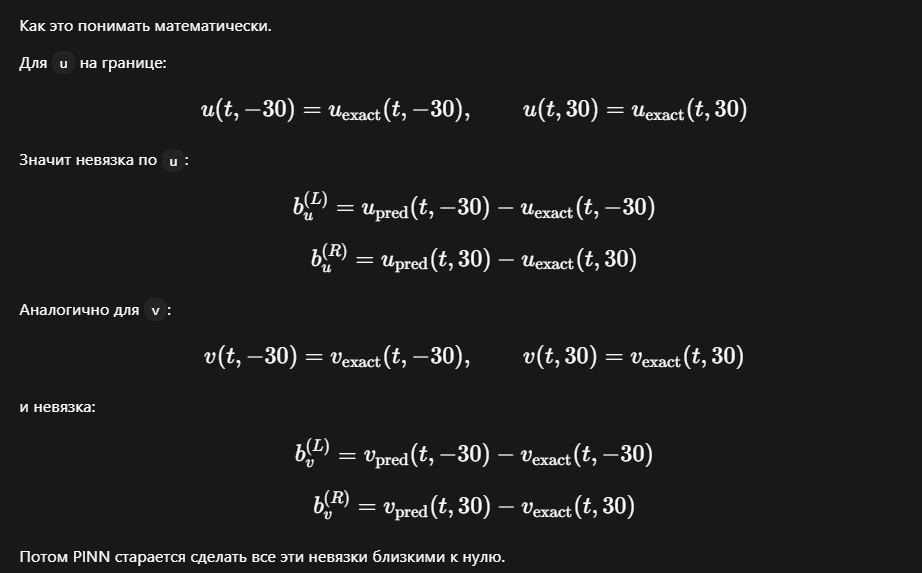

In [30]:
def residuals_from_fields(fields):
    """
    fields содержит:
    u, v, u_t, u_x, u_xx, v_t, v_x, v_xx
    """

    r_u = fields['u_t'] + us * fields['u'] * fields['u_x'] + fields['v'] + fields['v_xx']
    r_v = fields['v'] - fields['u_xx']

    return {
        'r_u': r_u,
        'r_v': r_v,
    }


def predict_uv(model_like, variant_name, X):
    with tf.device(TRAINING_DEVICE):
        if variant_name == 'two_models':
            u_pred = model_like['u'](X, training=False)
            v_pred = model_like['v'](X, training=False)
        else:
            y_pred = model_like(X, training=False)
            u_pred, v_pred = split_uv(y_pred)
    return u_pred, v_pred


def plot_training_snapshot(model_like, variant_name, step, plot_times=None, num_x=PLOT_NUM_X):
    if plot_times is None:
        plot_times = [tmin, 0.5 * (tmin + tmax), tmax]

    dtype = tf.dtypes.as_dtype(DTYPE)
    x_plot = tf.reshape(
        tf.linspace(tf.cast(xmin, dtype), tf.cast(xmax, dtype), num_x),
        (-1, 1),
    )
    x_np = x_plot.numpy().squeeze()

    fig, axes = plt.subplots(2, len(plot_times), figsize=(5 * len(plot_times), 7), sharex=True, squeeze=False)
    fig.suptitle(f'{variant_name}: approximation at step {step}', fontsize=14)

    for col, t_value in enumerate(plot_times):
        t_scalar = float(t_value)
        t_plot = tf.fill((num_x, 1), tf.cast(t_scalar, dtype))
        X_plot = stack_tx(t_plot, x_plot)

        u_pred, v_pred = predict_uv(model_like, variant_name, X_plot)
        u_true = u_exact(t_plot, x_plot)
        v_true = v_exact(t_plot, x_plot)

        u_pred_np = u_pred.numpy().squeeze()
        v_pred_np = v_pred.numpy().squeeze()
        u_true_np = u_true.numpy().squeeze()
        v_true_np = v_true.numpy().squeeze()

        mae_u = float(np.mean(np.abs(u_pred_np - u_true_np)))
        mae_v = float(np.mean(np.abs(v_pred_np - v_true_np)))

        axes[0, col].plot(x_np, u_true_np, label='exact', lw=2)
        axes[0, col].plot(x_np, u_pred_np, '--', label='pred', lw=2)
        axes[0, col].set_title(f't = {t_scalar:.2f}, MAE(u) = {mae_u:.2e}')
        axes[0, col].set_ylabel('u(t, x)')

        axes[1, col].plot(x_np, v_true_np, label='exact', lw=2)
        axes[1, col].plot(x_np, v_pred_np, '--', label='pred', lw=2)
        axes[1, col].set_title(f't = {t_scalar:.2f}, MAE(v) = {mae_v:.2e}')
        axes[1, col].set_xlabel('x')
        axes[1, col].set_ylabel('v(t, x)')

    axes[0, 0].legend()
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


def boundary_residuals_from_exact(model_like, variant_name, X_lb, X_ub):

    t_lb, x_lb = X_lb[:, 0:1], X_lb[:, 1:2]
    t_ub, x_ub = X_ub[:, 0:1], X_ub[:, 1:2]

    u_lb_pred, v_lb_pred = predict_uv(model_like, variant_name, X_lb)
    u_ub_pred, v_ub_pred = predict_uv(model_like, variant_name, X_ub)

    u_lb_exact = u_exact(t_lb, x_lb)
    u_ub_exact = u_exact(t_ub, x_ub)

    v_lb_exact = v_exact(t_lb, x_lb)
    v_ub_exact = v_exact(t_ub, x_ub)

    b_u = tf.concat([
        u_lb_pred - u_lb_exact,
        u_ub_pred - u_ub_exact,
    ], axis=0)

    b_v = tf.concat([
        v_lb_pred - v_lb_exact,
        v_ub_pred - v_ub_exact,
    ], axis=0)

    return {
        'b_u': b_u,
        'b_v': b_v,
    }


## 11. Функция потерь для каждого варианта

In [31]:
def select_fields(model_like, variant_name, X):
    if variant_name == 'two_output':
        return derivatives_two_output_model(model_like, X)
    if variant_name == 'two_models':
        return derivatives_two_models(model_like['u'], model_like['v'], X)
    if variant_name == 'shared_trunk':
        return derivatives_two_output_model(model_like, X)
    raise ValueError(f'Unknown variant_name: {variant_name}')


def initial_condition_loss(model_like, variant_name, X_0, u_0, v_0):
    fields_0 = select_fields(model_like, variant_name, X_0)
    phi_0_u = mse(fields_0['u'] - u_0)
    phi_0_v = mse(fields_0['v'] - v_0)
    return {
        'phi_0_u': phi_0_u,
        'phi_0_v': phi_0_v,
        'phi_0': phi_0_u + phi_0_v,
    }


def compute_total_loss(model_like, variant_name, X_r, X_0, u_0, v_0, X_lb, X_ub):
    fields_r = select_fields(model_like, variant_name, X_r)
    residuals = residuals_from_fields(fields_r)
    bc = boundary_residuals_from_exact(model_like, variant_name, X_lb, X_ub)
    ic = initial_condition_loss(model_like, variant_name, X_0, u_0, v_0)

    phi_r = tf.add_n([mse(val) for val in residuals.values()])
    phi_b = tf.add_n([mse(val) for val in bc.values()])
    phi_0 = ic['phi_0']

    total_loss = lambda_r * phi_r + lambda_b * phi_b + lambda_0 * phi_0

    metrics = {
        'total': total_loss,
        'phi_r': phi_r,
        'phi_b': phi_b,
        'phi_0': phi_0,
    }
    metrics.update(ic)
    return total_loss, metrics


## 12. Шаг обучения и цикл тренировки

Здесь один и тот же каркас можно использовать для всех трех вариантов.

In [32]:
def trainable_variables_for_variant(model_like, variant_name):
    if variant_name == 'two_models':
        return model_like['u'].trainable_variables + model_like['v'].trainable_variables
    return model_like.trainable_variables


def build_variant_for_training(model_like, optimizer, variant_name):
    dtype = tf.dtypes.as_dtype(DTYPE)
    dummy_X = tf.zeros((1, 2), dtype=dtype)

    if variant_name == 'two_models':
        model_like['u'](dummy_X, training=False)
        model_like['v'](dummy_X, training=False)
    else:
        model_like(dummy_X, training=False)

    variables = list(trainable_variables_for_variant(model_like, variant_name))
    if hasattr(optimizer, 'build'):
        optimizer.build(variables)
    return variables


def make_train_step(model_like, optimizer, variant_name):
    build_variant_for_training(model_like, optimizer, variant_name)

    @tf.function(reduce_retracing=True)
    def train_step_fn(X_r, X_0, u_0, v_0, X_lb, X_ub):
        with tf.device(TRAINING_DEVICE):
            with tf.GradientTape() as tape:
                total_loss, metrics = compute_total_loss(model_like, variant_name, X_r, X_0, u_0, v_0, X_lb, X_ub)

            variables = tuple(trainable_variables_for_variant(model_like, variant_name))
            grads = tape.gradient(total_loss, variables)
            grads_and_vars = [(grad, var) for grad, var in zip(grads, variables) if grad is not None]
            if grads_and_vars:
                optimizer.apply_gradients(grads_and_vars)
        return metrics

    return train_step_fn


def run_training(model_like, optimizer, variant_name, num_steps=NUM_STEPS, print_every=PRINT_EVERY, plot_every=PLOT_EVERY, plot_times=None, plot_num_x=PLOT_NUM_X):
    history = {
        'step': [],
        'total': [],
        'phi_r': [],
        'phi_b': [],
        'phi_0': [],
    }

    print(f'[{variant_name}] training device: {TRAINING_DEVICE}')
    train_step_fn = make_train_step(model_like, optimizer, variant_name)
    t0 = time()
    for step in range(num_steps + 1):
        metrics = train_step_fn(X_r, X_0, u_0, v_0, X_lb, X_ub)

        history['step'].append(step)
        history['total'].append(float(metrics['total']))
        history['phi_r'].append(float(metrics['phi_r']))
        history['phi_b'].append(float(metrics['phi_b']))
        history['phi_0'].append(float(metrics['phi_0']))

        if step % print_every == 0:
            print(f"[{variant_name}] step={step:05d} total={float(metrics['total']):.6e}")

        if plot_every and step > 0 and step % plot_every == 0:
            plot_training_snapshot(model_like, variant_name, step, plot_times=plot_times, num_x=plot_num_x)

    print(f'[{variant_name}] elapsed: {time() - t0:.2f} sec')
    return history


## 13. Инициализация трех подходов

In [33]:
with tf.device(TRAINING_DEVICE):
    two_output_model = TwoOutputPINN(
        num_hidden_layers=NUM_HIDDEN_LAYERS,
        hidden_dim=HIDDEN_DIM,
        num_fourier=NUM_FOURIER,
        activation=ACTIVATION,
    )
    two_output_optim = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

    two_models = {
        'u': SingleOutputPINN(
            num_hidden_layers=NUM_HIDDEN_LAYERS,
            hidden_dim=HIDDEN_DIM,
            num_fourier=NUM_FOURIER,
            activation=ACTIVATION,
            name='model_u',
        ),
        'v': SingleOutputPINN(
            num_hidden_layers=NUM_HIDDEN_LAYERS,
            hidden_dim=HIDDEN_DIM,
            num_fourier=NUM_FOURIER,
            activation=ACTIVATION,
            name='model_v',
        ),
    }
    two_models_optim = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

    shared_trunk_model = SharedTrunkPINN(
        num_shared_layers=NUM_SHARED_LAYERS,
        hidden_dim=HIDDEN_DIM,
        num_fourier=NUM_FOURIER,
        activation=ACTIVATION,
    )
    shared_trunk_optim = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)


## 14. Запуск экспериментов

Снимите комментарии после того, как заполните `u_exact`, `v_exact`, `residuals_from_fields` и `boundary_residuals_from_exact`.

[two_output] training device: /CPU:0
[two_output] step=00000 total=3.509710e+00
[two_output] step=00100 total=2.679545e-02
[two_output] step=00200 total=1.165983e-02
[two_output] step=00300 total=7.901165e-03
[two_output] step=00400 total=6.172580e-03
[two_output] step=00500 total=5.194267e-03
[two_output] step=00600 total=4.579838e-03
[two_output] step=00700 total=4.167687e-03
[two_output] step=00800 total=3.876409e-03
[two_output] step=00900 total=3.660093e-03
[two_output] step=01000 total=3.491303e-03
[two_output] step=01100 total=3.353194e-03
[two_output] step=01200 total=3.235269e-03
[two_output] step=01300 total=3.130895e-03
[two_output] step=01400 total=3.035797e-03
[two_output] step=01500 total=2.947155e-03
[two_output] step=01600 total=2.863062e-03
[two_output] step=01700 total=2.782191e-03
[two_output] step=01800 total=2.703596e-03
[two_output] step=01900 total=2.626584e-03
[two_output] step=02000 total=2.550632e-03


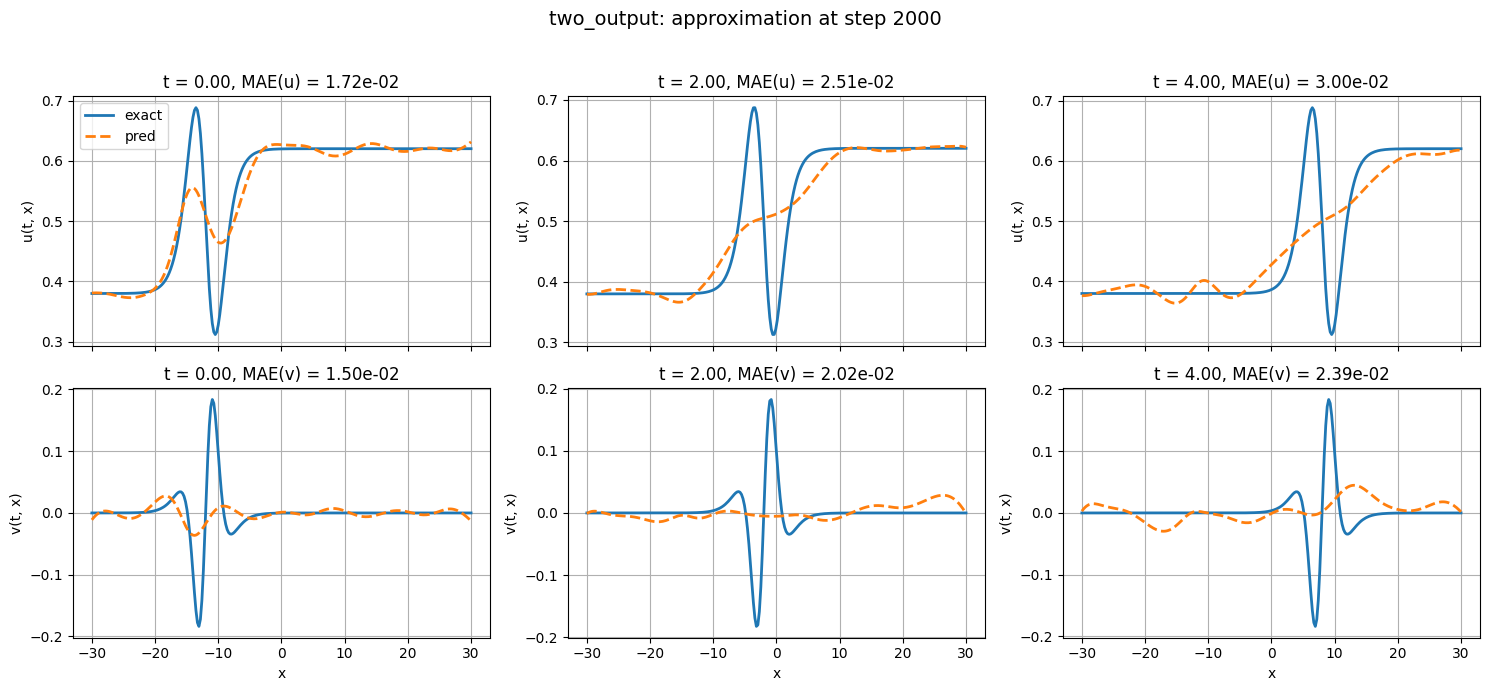

[two_output] step=02100 total=2.475340e-03
[two_output] step=02200 total=2.400396e-03
[two_output] step=02300 total=2.325567e-03
[two_output] step=02400 total=2.250690e-03
[two_output] step=02500 total=2.175676e-03


KeyboardInterrupt: 

In [34]:
with tf.device(TRAINING_DEVICE):
    history_two_output = run_training(two_output_model, two_output_optim, 'two_output', num_steps=NUM_STEPS, print_every=PRINT_EVERY, plot_every=PLOT_EVERY)
    histor_two_models = run_training(two_models, two_models_optim, 'two_models', num_steps=NUM_STEPS, print_every=PRINT_EVERY, plot_every=PLOT_EVERY)
    history_shared_trunk = run_training(shared_trunk_model, shared_trunk_optim, 'shared_trunk', num_steps=NUM_STEPS, print_every=PRINT_EVERY, plot_every=PLOT_EVERY)


## 15. Сравнение графиков потерь

In [ ]:
def load_history_from_notebook(nb_path='start.ipynb'):
    nb_path = Path(nb_path)
    with nb_path.open('r', encoding='utf-8') as f:
        nb = json.load(f)

    pattern = re.compile(
        r"It\s+(\d+):\s+total=([0-9.eE+-]+),\s+phi_r=([0-9.eE+-]+),\s+phi_b=([0-9.eE+-]+),\s+phi_0=([0-9.eE+-]+)"
    )

    history = {
        'step': [],
        'total': [],
        'phi_r': [],
        'phi_b': [],
        'phi_0': [],
    }

    for cell in nb.get('cells', []):
        for output in cell.get('outputs', []):
            if output.get('output_type') != 'stream':
                continue

            text = output.get('text', '')
            if isinstance(text, list):
                text = ''.join(text)

            for match in pattern.finditer(text):
                history['step'].append(int(match.group(1)))
                history['total'].append(float(match.group(2)))
                history['phi_r'].append(float(match.group(3)))
                history['phi_b'].append(float(match.group(4)))
                history['phi_0'].append(float(match.group(5)))

    if not history['step']:
        raise ValueError(f'Не удалось извлечь history из {nb_path}')

    return history


def plot_histories(histories, stage1_history=None, stage1_label='stage1'):
    plt.figure(figsize=(9, 4))

    if stage1_history is not None:
        plt.semilogy(stage1_history['step'], stage1_history['total'], '--', lw=2, label=stage1_label)

    for label, history in histories.items():
        plt.semilogy(history['step'], history['total'], label=label)

    plt.xlabel('iteration')
    plt.ylabel('total loss')
    plt.title('Сравнение сходимости: этап 1 и три подхода этапа 2')
    plt.legend()
    plt.tight_layout()
    plt.show()


def summarize_history(history, label):
    total = np.array(history['total'])
    steps = np.array(history['step'])
    best_idx = int(np.argmin(total))

    return {
        'label': label,
        'best_step': int(steps[best_idx]),
        'best_total': float(total[best_idx]),
        'final_total': float(total[-1]),
    }


def print_history_summary(histories, stage1_history=None, stage1_label='stage1'):
    rows = []
    if stage1_history is not None:
        rows.append(summarize_history(stage1_history, stage1_label))

    for label, history in histories.items():
        rows.append(summarize_history(history, label))

    for row in rows:
        print(
            f"{row['label']}: best_step={row['best_step']}, "
            f"best_total={row['best_total']:.6e}, final_total={row['final_total']:.6e}"
        )


# Пример использования:
# stage1_history = load_history_from_notebook('start.ipynb')
# plot_histories({
#     'two_output': history_two_output,
#     'two_models': history_two_models,
#     'shared_trunk': history_shared_trunk,
# }, stage1_history=stage1_history, stage1_label='stage1_start')
# print_history_summary({
#     'two_output': history_two_output,
#     'two_models': history_two_models,
#     'shared_trunk': history_shared_trunk,
# }, stage1_history=stage1_history, stage1_label='stage1_start')


## 16. Сравнение с этапом 1

По ТЗ нужно сравнить график сходимости этапа 2 с результатами этапа 1.

В этом шаблоне это делается так:

1. функция `load_history_from_notebook('start.ipynb')` читает сохраненный лог обучения из ноутбука первого этапа;
2. `plot_histories(..., stage1_history=...)` накладывает кривую этапа 1 на графики этапа 2;
3. `print_history_summary(...)` печатает краткую сводку по лучшему и финальному лоссу.

In [ ]:
stage1_history = load_history_from_notebook('start.ipynb')
plot_histories({
    'two_output': history_two_output,
    'two_models': history_two_models,
    'shared_trunk': history_shared_trunk,
}, stage1_history=stage1_history, stage1_label='stage1_start')
print_history_summary({
    'two_output': history_two_output,
    'two_models': history_two_models,
    'shared_trunk': history_shared_trunk,
}, stage1_history=stage1_history, stage1_label='stage1_start')


## 17. Шаблон сравнительного анализа

Заполните этот блок после запуска всех экспериментов.

**Сравнение с этапом 1**

- Лучшее значение функции потерь на этапе 1: `...`
- Лучшее значение функции потерь на этапе 2 для каждой архитектуры: `...`
- Какая архитектура приблизилась к решению быстрее относительно этапа 1: `...`
- Есть ли более сильные колебания лосса по сравнению с этапом 1: `...`

**Сравнение трёх подходов этапа 2**

- Одна сеть с двумя выходами: сильные стороны `...`, слабые стороны `...`
- Две отдельные сети: сильные стороны `...`, слабые стороны `...`
- Shared trunk + две головы: сильные стороны `...`, слабые стороны `...`

**Итоговый вывод**

- Наиболее устойчивый подход: `...`
- Наиболее точный подход по итоговому лоссу: `...`
- Какой подход вы считаете наиболее удачным и почему: `...`


## 18. Мини-чеклист перед запуском

Что нужно заполнить вручную:

1. `u_exact(t, x)`
2. `v_exact(t, x)`
3. `residuals_from_fields(fields)`
4. `boundary_residuals_from_exact(...)`
5. при необходимости коэффициенты уравнения
6. число шагов обучения и гиперпараметры

Какие функции у вас уже готовы по именам:

- `TwoOutputPINN`
- `SingleOutputPINN`
- `SharedTrunkPINN`
- `derivatives_two_output_model`
- `derivatives_two_models`
- `compute_total_loss`
- `train_step`
- `run_training`
- `load_history_from_notebook`
- `plot_histories`
- `print_history_summary`

Если захотите, следующий шаг я могу сделать тоже за вас: заполнить сюда формулы именно под вашу систему после подстановки.